# Script for Exercise 2 ("Load analysis to evaluate the need for flexibility")

Intro script for Exercise 2 in specialization course module 
"Flexibility in power grid operation and planning" at NTNU (TET4565/TET4575) 

In [39]:
# Dependencies

import pandapower as pp
import pandapower.plotting as pp_plotting
import pandas as pd
import os
import load_scenarios as ls
import load_profiles as lp
import pandapower_read_csv as ppcsv
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [40]:
# Define input data

# Location of (processed) data set for CINELDI MV reference system
# (to be replaced by your own local data folder)
path_data_set         = 'C:/Users/Eier/OneDrive - NTNU/9. Semester/Fordypningsemne, Kraftmarkeder/Module 1, Flexibility/7703070'

filename_load_data_fullpath = os.path.join(path_data_set,'load_data_CINELDI_MV_reference_system.csv')
filename_load_mapping_fullpath = os.path.join(path_data_set,'mapping_loads_to_CINELDI_MV_reference_grid.csv')

# Subset of load buses to consider in the grid area, considering the area at the end of the main radial in the grid
bus_i_subset = [90, 91, 92, 96]

# Assumed power flow limit in MW that limit the load demand in the grid area (through line 85-86)
P_lim = 0.637 

# Maximum load demand of new load being added to the system
P_max_new = 0.4

# Which time series from the load data set that should represent the new load
i_time_series_new_load = 90

In [41]:
# Read pandapower network

net = ppcsv.read_net_from_csv(path_data_set, baseMVA=10)

c:\Users\Eier\OneDrive - NTNU\9. Semester\Fordypningsemne, Kraftmarkeder\Module 1, Flexibility\CINELDI_MV_reference_system-flexibility_course_NTNU_public\pandapower_read_csv.py:123: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  res_bus = pd.concat([res_bus, res_row])


In [42]:
# Extract hourly load time series for a full year for all the load points in the CINELDI reference system
# (this code is made available for solving task 3)

load_profiles = lp.load_profiles(filename_load_data_fullpath)

# Get all the days of the year
repr_days = list(range(1,366))

# Get normalized load profiles for representative days mapped to buses of the CINELDI reference grid;
# the column index is the bus number (1-indexed) and the row index is the hour of the year (0-indexed)
profiles_mapped = load_profiles.map_rel_load_profiles(filename_load_mapping_fullpath,repr_days)

# Retrieve normalized load time series for new load to be added to the area
new_load_profiles = load_profiles.get_profile_days(repr_days)
new_load_time_series = new_load_profiles[i_time_series_new_load]*P_max_new

# Calculate load time series in units MW (or, equivalently, MWh/h) by scaling the normalized load time series by the
# maximum load value for each of the load points in the grid data set (in units MW); the column index is the bus number
# (1-indexed) and the row index is the hour of the year (0-indexed)
load_time_series_mapped = profiles_mapped.mul(net.load['p_mw'])

c:\Users\Eier\OneDrive - NTNU\9. Semester\Fordypningsemne, Kraftmarkeder\Module 1, Flexibility\CINELDI_MV_reference_system-flexibility_course_NTNU_public\load_profiles.py:46: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loaddata.index = pd.to_datetime([d + " " + "%.2d" % (int(t) - 1) for d, t in timestamp_list], dayfirst=True)
c:\Users\Eier\OneDrive - NTNU\9. Semester\Fordypningsemne, Kraftmarkeder\Module 1, Flexibility\CINELDI_MV_reference_system-flexibility_course_NTNU_public\load_profiles.py:87: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  profile_days = pd.concat([profile_days, profile_day])
c:\Users\Eier\OneDrive - NTNU\9. Se

Total load demand in the system assuming a peak load model: 6.4071772849999995 MW


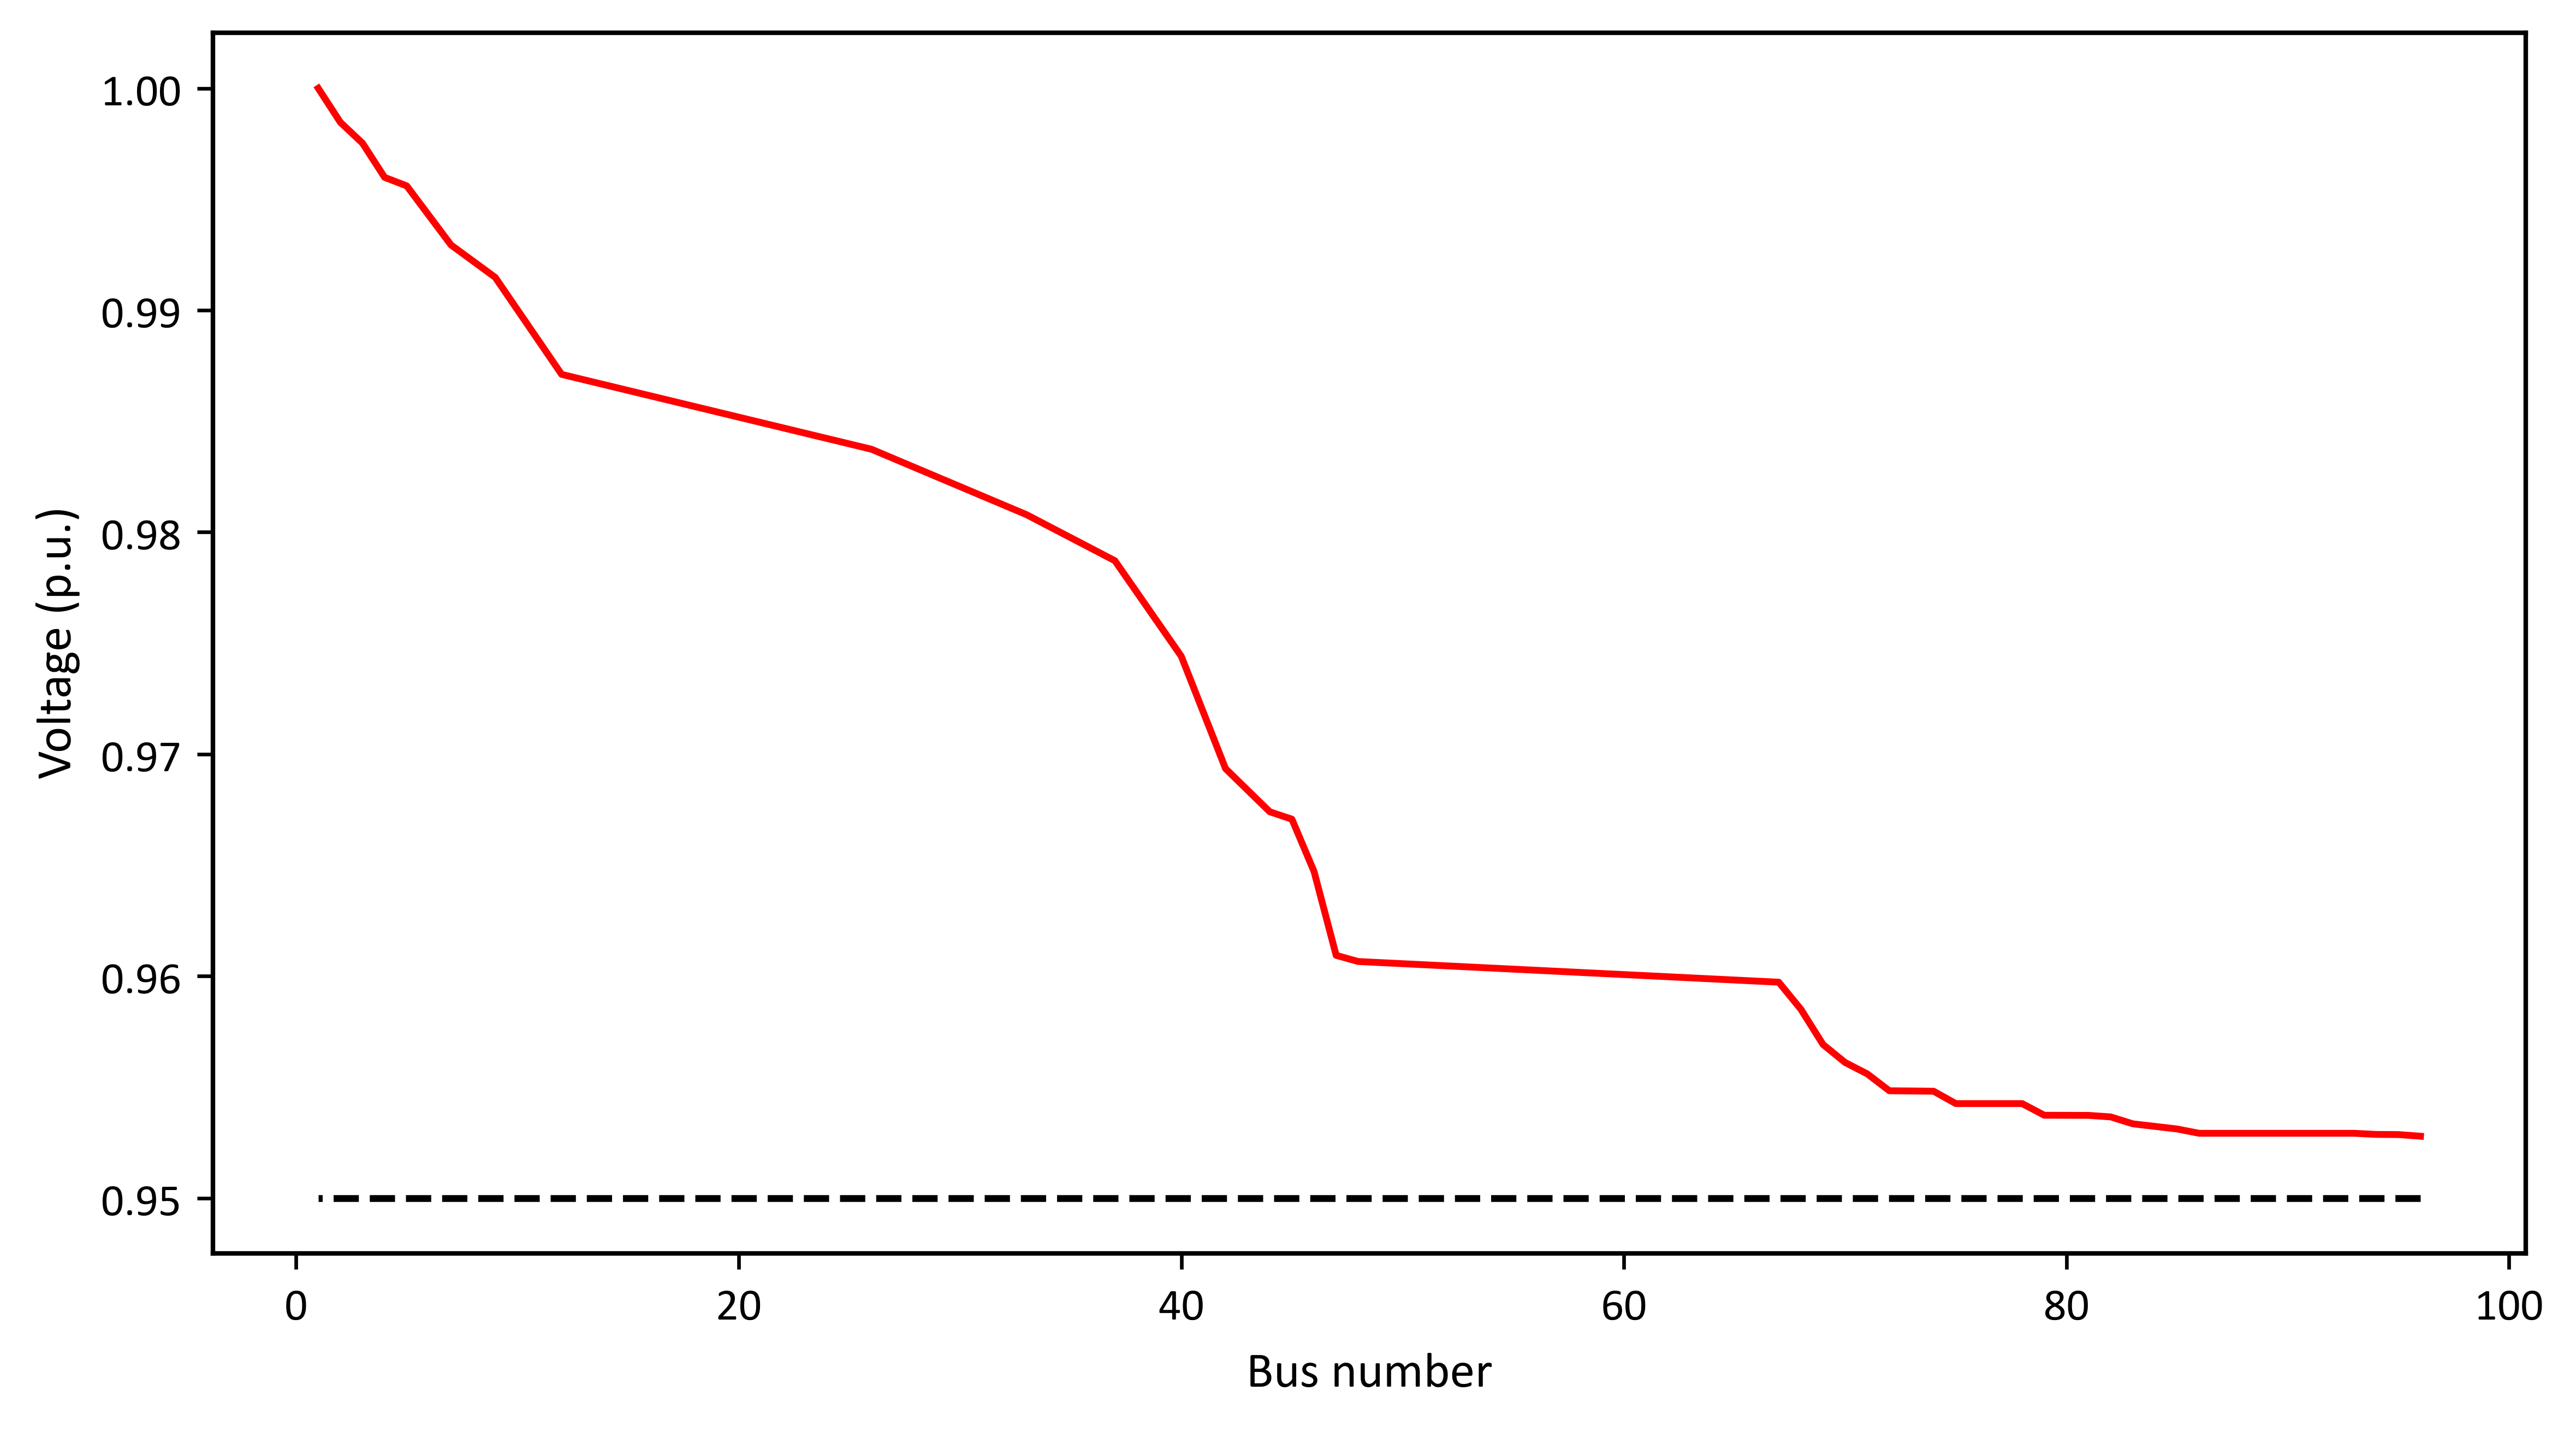

Minimum voltage in grid: 0.9528 p.u.


In [43]:
#Task 1: Plot the voltage profile in the grid and find how low the voltage drops
#The code in this cell is imported from exercise_0_battery_in_the_reference_system.py: 
# Test running power flow with a peak load model
# (i.e., all loads are assumed to be at their annual peak load simultaneously)

pp.runpp(net,init='results',algorithm='bfsw')

print('Total load demand in the system assuming a peak load model: ' + str(net.res_load['p_mw'].sum()) + ' MW')

# %%
# Calculate voltage profile

buses = []
voltage_profile = []

# Start from bus 96 (where we assume that a new customer will be connected)
next_bus = 96

# Trace the radial (tree graph) back to bus 1 (the main feeder HV/MV substation) 
while next_bus != 1:
    prev_bus = next_bus
    next_bus = min(list(pp.toolbox.get_connected_buses(net,next_bus)))
    U = net.res_bus.loc[prev_bus,'vm_pu']
    voltage_profile += [U]
    buses += [prev_bus]

#For task 1: Adding bus 1 to the voltage profile and bus list
buses += [1]
voltage_profile += [net.res_bus.loc[1, 'vm_pu']]


# NB: Here we have not actually checked whether bus 96 is at the end of the radial

# %%
# Plot voltage profile

# Settings for plotting
mpl.rcParams.update({
    'font.family': 'Calibri',    #
    'font.size': 11,           #
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'axes.linewidth': 1,
    'grid.linewidth': 0.5,
    'legend.frameon': False
})
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Calibri'

fig, ax = plt.subplots(figsize=(8, 4.5),dpi=600)
plt.plot(buses,voltage_profile, 'r')
plt.plot([buses[0], buses[-1]],[0.95, 0.95], 'k--')
ax.set_xlabel('Bus number')
ax.set_ylabel('Voltage (p.u.)')
plt.tight_layout()
plt.show()

print(f'Minimum voltage in grid: {min(voltage_profile):.4f} p.u.')

 # NB: We know that bus 96 has the lowest voltage value in the grid but we have not actually checked this in the code above


      bus      p_mw
name               
90     90  0.043782
91     91  0.153540
92     92  0.073773
96     96  0.183789
Sum: 0.454883499 MW


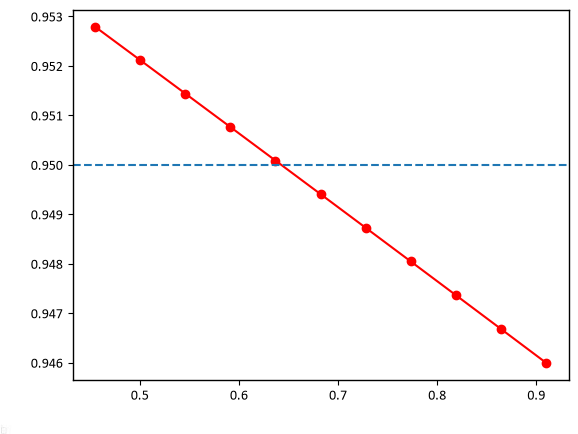

In [44]:
#Task 2: Find how much the voltages decrease as the load demand in the area increases
# table showing the load demand values of all four existing load points in the area (on bus 90, 91, 92 and 96) and their sum (i.e., the aggregated load demand in the area).
load_area = net.load[net.load['bus'].isin(bus_i_subset)] # Select the four loads in the area (bus 90, 91, 92, 96)
print(load_area[['bus', 'p_mw']])# table of peak loads
print('Sum:', load_area['p_mw'].sum(), 'MW')# sum of aggregated load in the area

#Multiply each load proportionally by a scaling factor
P_area = [] # aggregated load for each scaling facto
U_min = [] # lowest voltage for each scaling factor

for s in np.arange(1, 2.05, 0.1):
    net.load.loc[bus_i_subset, 'scaling'] = s # scale the loads in the area
    pp.runpp(net) # run power flow
    P_area.append(load_area['p_mw'].sum() * s)
    U_min.append(net.res_bus.loc[96, 'vm_pu']) #bus 96 is the bus with lowest voltage in area. 

net.load.loc[bus_i_subset, 'scaling'] = 1 #reseting scaling factor to 1 for comming tasks

#Plot the lowest voltage value in the area as a function of the aggregated load demand in the area, compare with the voltage limit of 0.95 p.u
plt.plot(P_area, U_min, 'r-o')
plt.axhline(0.95, linestyle='--')  # voltage limit
plt.xlabel('Total Load (MW)')
plt.ylabel('Minimum Voltage (p.u.)')
plt.show()


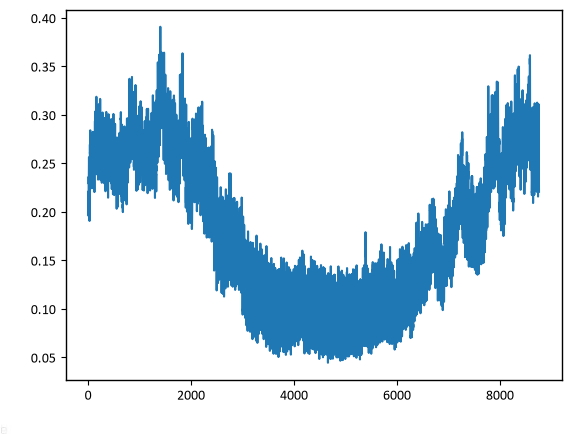

Max aggregated load: 0.3908869060128244 MW


In [45]:
# Task 3: Plot the aggregated load demand time series for the grid area
P_agg = load_time_series_mapped[bus_i_subset].sum(axis=1)   # sum of the four loads for each hour

plt.plot(P_agg)
plt.xlabel('Hour of the year')
plt.ylabel('Aggregated load (MW)')
plt.show()

print('Max aggregated load:', P_agg.max(), 'MW')

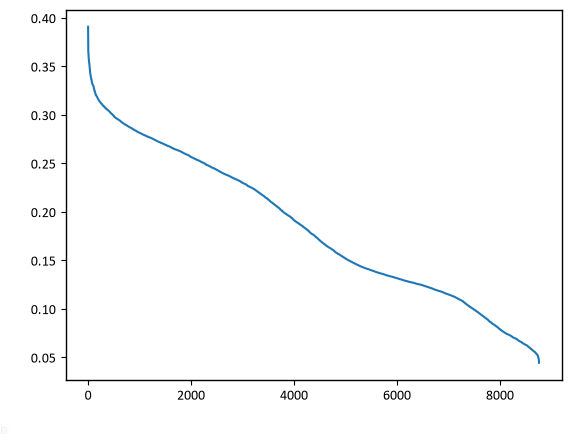

In [46]:
#Task 4: Plot a load duration curve for the aggregated load time series

P_sorted = P_agg.sort_values(ascending=False).values   # sort hourly loads from highest to lowest
plt.plot(P_sorted)
plt.xlabel('Hours')
plt.ylabel('Aggregated load (MW)')
plt.show()

In [47]:
# Task 5:Calculate and explain the utilization time for the loads
T = P_agg.sum() / P_agg.max()   # Utilization time (h)= annual energy (MWh) / peak load (MW)
print('Utilization time:', T, 'hours')

Utilization time: 4125.387975210684 hours


In [48]:
#Task 6: Calculate and explain the coincidence factor for the loads.
sum_individual_peaks = load_time_series_mapped[bus_i_subset].max().sum()
print('Coincidence factor:', P_agg.max() / sum_individual_peaks) #Coincidence factor = peak of aggregated load / sum of individual peaks


Coincidence factor: 0.8593121246915671


In [49]:
#Task 7: What is the hosting capacity of the area with respect to the power flow limit 0.637 MW. 

print('Hosting capacity:', P_lim - P_agg.max()) # (assuming responsibility factor (s) of new load = 1)

Hosting capacity: 0.24611309398717562


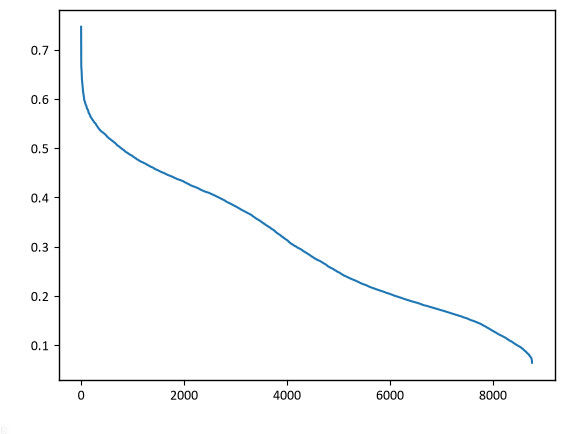

Max aggregated load after new load added: 0.7464469855705876 MW


In [50]:
#Task 8: Plot the load duration curve for the grid area after a new load has been added

P_agg_new = P_agg + new_load_time_series.values   # existing load + new load, hour by hour
P_agg_new_sorted = P_agg_new.sort_values(ascending=False).values   # sort hourly loads from highest to lowest

plt.plot(P_agg_new_sorted)
plt.xlabel('Hours')
plt.ylabel('Aggregated load (MW)')
plt.show()

print('Max aggregated load after new load added:', P_agg_new.max(), 'MW')

In [51]:
#Task 9: Find the number of hours per year that the load demand would have to be reduced to avoid congestion
print('Congested hours:',(P_agg_new > P_lim).sum()) #Number of hours higher than the power flow limit 

Congested hours: 19


Max power reduction: 0.10944698557058763 MW
Total energy to reduce: 0.47716927978535006 MWh


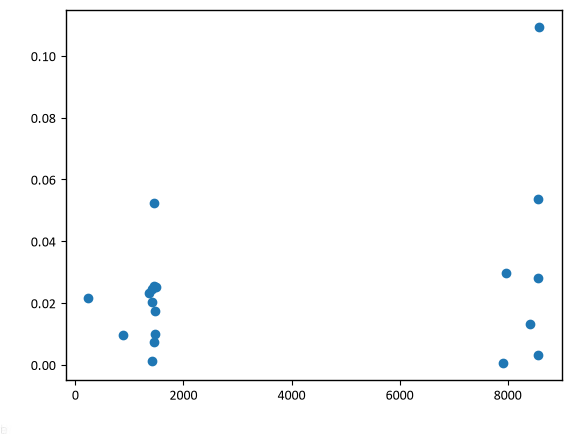

DatetimeIndex(['1970-01-10 19:00:00', '1970-02-06 20:00:00',
               '1970-02-26 22:00:00', '1970-02-28 18:00:00',
               '1970-02-28 20:00:00', '1970-02-28 21:00:00',
               '1970-03-02 16:00:00', '1970-03-02 17:00:00',
               '1970-03-02 18:00:00', '1970-03-03 11:00:00',
               '1970-03-03 18:00:00', '1970-03-03 20:00:00',
               '1970-11-26 21:00:00', '1970-11-28 15:00:00',
               '1970-12-17 20:00:00', '1970-12-23 12:00:00',
               '1970-12-23 13:00:00', '1970-12-23 22:00:00',
               '1970-12-24 11:00:00'],
              dtype='datetime64[ns]', freq=None)


In [52]:
#Task 10: Characterize the need for flexibility in the area
excess = P_agg_new - P_lim          # load above (positive) or below (negative) the limit each hour
excess = excess[excess > 0]         # keep only the hours above the limit (positive)

print('Max power reduction:', excess.max(), 'MW')
print('Total energy to reduce:', excess.sum(), 'MWh')

plt.plot(excess,'o') #plotting the hours where the load is above the limit
plt.xlabel('Hour of the year')
plt.ylabel('Load above limit (MW)')
plt.show()

time_of_day = pd.to_datetime(excess.index, unit='h') #convert hour index to datetime format to extract time of day. To see which time of day the congestion occurs. 
print(time_of_day)

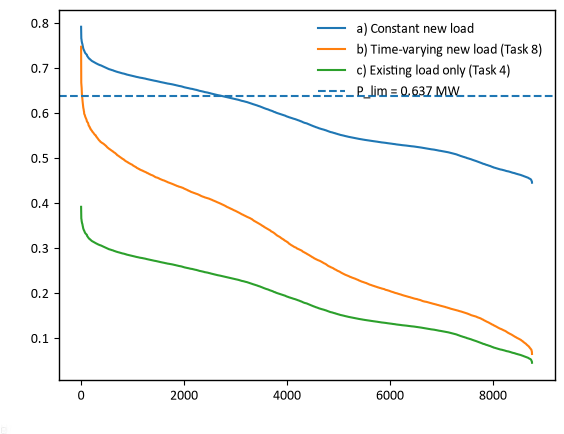

Congested hours (Constant new load): 2744


In [53]:
# Task 12: Compare load duration curves for different assumptions about the new load
P_agg_new_const=0.4 # Adding a constant load of 0.4MW
P_agg_const = P_agg + P_agg_new_const   # existing load + constant 0.4 MW new load

plt.plot(P_agg_const.sort_values(ascending=False).values, label='a) Constant new load')
plt.plot(P_agg_new.sort_values(ascending=False).values, label='b) Time-varying new load (Task 8)')
plt.plot(P_agg.sort_values(ascending=False).values, label='c) Existing load only (Task 4)')
plt.axhline(P_lim, linestyle='--', label='P_lim = 0.637 MW')
plt.xlabel('Hours')
plt.ylabel('Aggregated load (MW)')
plt.legend()
plt.show()

print('Congested hours (Constant new load):', (P_agg_const > P_lim).sum())

In [54]:

# Task 13: Compare utilization times and coincidence factors for different assumptions about the load
print('a) Utilization time:', P_agg_const.sum() / P_agg_const.max(), 'CF:', P_agg_const.max() / (sum_individual_peaks + P_agg_new_const))
print('b) Utilization time:', P_agg_new.sum() / P_agg_new.max(), 'CF:', P_agg_new.max() / (sum_individual_peaks + 0.4))  #b) new load also had 0.4 MW as peak load
print('c) Utilization time:', P_agg.sum() / P_agg.max(), 'CF:', P_agg.max() / sum_individual_peaks)

a) Utilization time: 6469.395437999132 CF: 0.9251399833286809
b) Utilization time: 3571.476202403954 CF: 0.873156384985491
c) Utilization time: 4125.387975210684 CF: 0.8593121246915671
